# Convolutional Neural Networks for Eye Disease Detection

## Authors

Laura Cahill, Olivia Jones-Martin, Roberto Mercado, Zuriel Pagan

## Dataset

We use the [Retinal Fundus Multi-disease Image Dataset (RFMiD)](https://ieee-dataport.org/open-access/retinal-fundus-multi-disease-image-dataset-rfmid?check_logged_in=1) for this project, which is available on the IEEE DataPort website. It contains 3200 fundus color images captured by three different fundus cameras. The dataset is divided into a training set of 1920 images, validation set of 640 images, and testing set of 640 images. Ground truth labels are provided through CSV files, which account for 1 healthy class and 45 disease classes.

## Prerequisites

The following Python 3.12 modules are required to execute the cells of this notebook.

In [55]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from utilities import *
import pandas as pd

The following constants assume that the "All Classes" version of the dataset was downloaded from the IEEE DataPort website and placed into the same directory as this notebook.

In [56]:
DATA_PATH = 'A. RFMiD_All_Classes_Dataset'
IMAGE_PATH = f'{DATA_PATH}/1. Original Images'
GROUND_TRUTH_PATH = f'{DATA_PATH}/2. Groundtruths'
TRAINING_SET_PATH = f'{IMAGE_PATH}/a. Training Set'
VALIDATION_SET_PATH = f'{IMAGE_PATH}/b. Validation Set'
TESTING_SET_PATH = f'{IMAGE_PATH}/c. Testing Set'

GPU access is a must for complex neural networks. Running the Inception v3 model on the CPU is ill-advised.

In [57]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
display(device)

device(type='cuda')

## Dataset Setup

First, we need to set up the dataset for model evaluation. The dataset is presplit into training, validation, and testing sets already. However, we need to make sure that the healthy class can be properly classified. We can modify the metadata to address this.

In [58]:
training_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/a. RFMiD_Training_Labels.csv')
validation_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/b. RFMiD_Validation_Labels.csv')
testing_metadata = pd.read_csv(f'{GROUND_TRUTH_PATH}/c. RFMiD_Testing_Labels.csv')

for metadata in (training_metadata, validation_metadata, testing_metadata):
    metadata.rename(columns={'Disease_Risk' : 'Healthy'}, inplace=True)
    metadata['Healthy'] = metadata['Healthy'].apply(lambda value: int(not value))

Now, let's configure the dataset for use by Inception v3. The FundusImageDataset class will handle the underlying logic for loading images and labels. We only need to supply the transform so that our images are properly sized for the model.

In [59]:
transform = transforms.Compose([
    transforms.Resize(299),
    transforms.CenterCrop(299),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

training_dataset = FundusImageDataset(training_metadata, TRAINING_SET_PATH, transform)
validation_dataset = FundusImageDataset(validation_metadata, VALIDATION_SET_PATH, transform)
testing_dataset = FundusImageDataset(testing_metadata, TESTING_SET_PATH, transform)

batch_size = 32
num_workers = 16

training_sampler = torch.utils.data.RandomSampler(training_dataset)
validation_sampler = torch.utils.data.RandomSampler(validation_dataset)
testing_sampler = torch.utils.data.SequentialSampler(testing_dataset)

training_loader = DataLoader(training_dataset, batch_size=batch_size, sampler=training_sampler, num_workers=num_workers)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, sampler=validation_sampler, num_workers=num_workers)
testing_loader = DataLoader(testing_dataset, batch_size=batch_size, sampler=testing_sampler, num_workers=num_workers)

## Model Setup

Here, we set up Inception v3 for use on our dataset.

In [60]:
model = models.inception_v3(init_weights=True)
model.fc = nn.Linear(model.fc.in_features, 46)
model.aux_logits = False
model.AuxLogits = None
model = model.to(device)
display(model)

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

Then, we set up the class weights, loss function, and optimizer.

In [61]:
combined_metadata = pd.concat([training_metadata, validation_metadata, testing_metadata], ignore_index=True)
frequencies = combined_metadata.drop('ID', axis=1).sum().to_numpy()
weights = torch.FloatTensor((len(combined_metadata) - frequencies) / frequencies)
weights = weights.to(device)
criterion = nn.BCEWithLogitsLoss(weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
display(weights)

tensor([   3.7833,    4.0633,   17.9349,    5.1185,   12.9130,   18.1617,
          25.8908,    9.5263,  122.0769,   39.5063,  117.5185,   51.4590,
           6.1910,   70.1111,  319.0000,  127.0000,   26.8261,   32.3333,
         289.9091,  122.0769,  187.2353,  127.0000,   44.0704,   58.2593,
         132.3333,   99.0000,  187.2353,  319.0000,  399.0000, 1599.0000,
        1599.0000,  639.0000, 1065.6666, 3199.0000,  799.0000,  354.5555,
         456.1429,  532.3333,  532.3333,  799.0000, 3199.0000,  799.0000,
         799.0000, 1599.0000, 3199.0000, 1599.0000], device='cuda:0')

## Model Evaluation

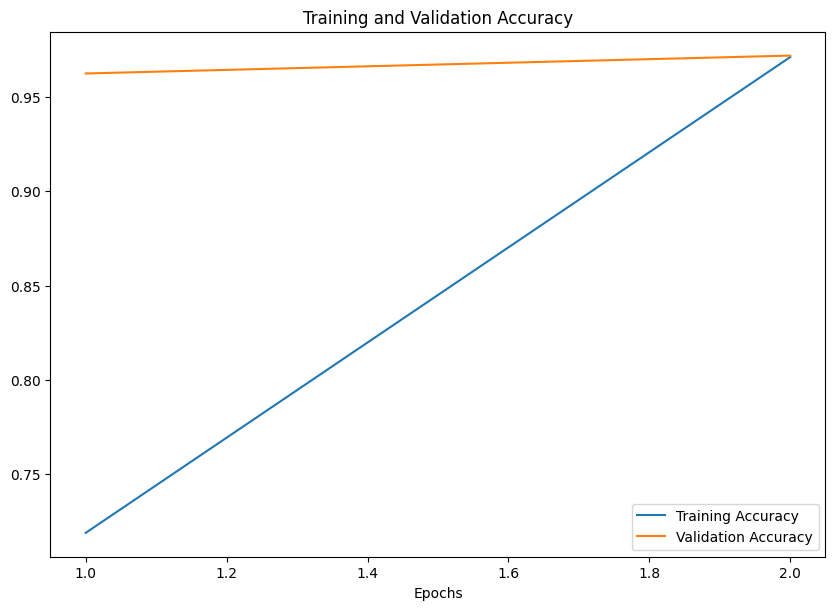

<Figure size 640x480 with 0 Axes>

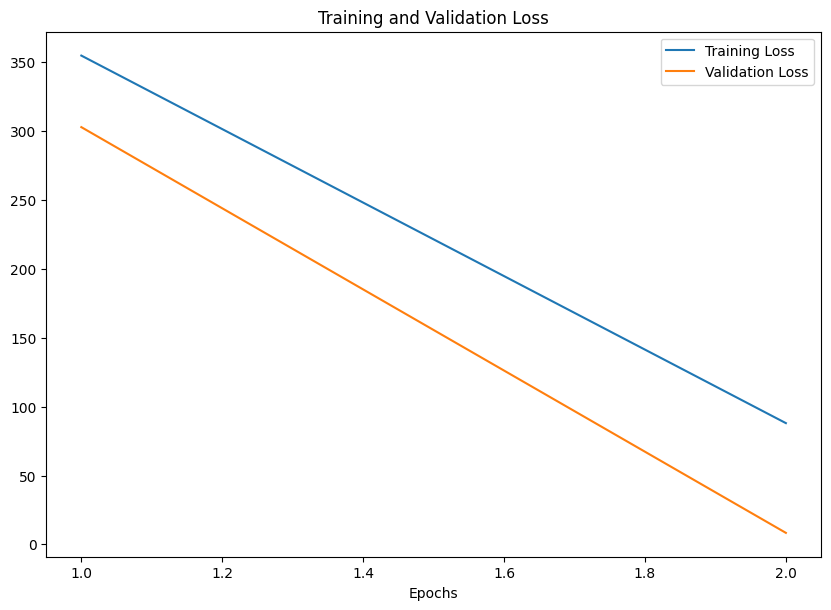

<Figure size 640x480 with 0 Axes>

In [62]:
evaluator = ModelEvaluator(
    training_loader,
    validation_loader,
    testing_loader,
    criterion,
    optimizer,
    device
)

results = evaluator.train(model, 2)
results.show_accuracies()
results.show_losses()

In [65]:
matrices = evaluator.test(model)
metrics = pd.DataFrame(index=testing_dataset.classes, data={
    'Accuracy' : [0.0] * len(testing_dataset.classes),
    'Precision' : [0.0] * len(testing_dataset.classes),
    'Recall' : [0.0] * len(testing_dataset.classes),
    'F1 Score' : [0.0] * len(testing_dataset.classes)
})

for label, matrix in zip(testing_dataset.classes, matrices):
    tn, fp, fn, tp = matrix.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f1_score = 2 * precision * recall / (precision + recall)
    metrics.at[label, 'Accuracy'] = accuracy
    metrics.at[label, 'Precision'] = precision
    metrics.at[label, 'Recall'] = recall
    metrics.at[label, 'F1 Score'] = f1_score

display(metrics)

/tmp/ipykernel_3829177/1804484808.py:12: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/tmp/ipykernel_3829177/1804484808.py:13: RuntimeWarning: invalid value encountered in scalar divide
  recall = tp / (tp + fn)


,Accuracy,Precision,Recall,F1 Score
Healthy,0.790625,NaN,0.0,NaN
DR,0.806250,NaN,0.0,NaN
ARMD,0.951562,NaN,0.0,NaN
MH,0.837500,NaN,0.0,NaN
DN,0.928125,NaN,0.0,NaN
MYA,0.950000,NaN,0.0,NaN
BRVO,0.964063,NaN,0.0,NaN
TSLN,0.917188,NaN,0.0,NaN
ERM,0.992188,NaN,0.0,NaN
LS,0.976562,NaN,0.0,NaN
